# Smart Spend

Smart spend adalah website berbasis AI yang digunakan untuk mengatur budgeting para pengguna. Ide project ini dibuat karena kurangnya orang dalam mengatur keuangan sehingga keadaan keuangan menjadi boncos. dengan adanya website berbasis AI ini diharapkan orang orang bisa mengatur budget sesuai dengan keadaan keuangan sekaligus rekomendasi dari Smart Spend

<hr>

Pembuatan Model Clustering untuk Sistem Rekomendasi

# Gathering Data

Import semua library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


Import Dataset

In [ ]:
url = "https://drive.google.com/uc?export=download&id=1n7t9XudgUGaJkETkJaSJAPSvvRE7VMOF"
df = pd.read_csv(url)
df.head()

,id,provinsi,klasifikasi_wilayah,jenis_kelamin,usia,pendidikan_terakhir,status_pekerjaan,status_pernikahan,jumlah_tanggungan,pendapatan_bulanan,...,pengeluaran_kesehatan,pengeluaran_pendidikan,pengeluaran_transportasi,pengeluaran_komunikasi,pengeluaran_hiburan_rekreasi,cicilan_hutang,tabungan_bulanan,rasio_tabungan_persen,skor_literasi_keuangan,label_rekomendasi
0,1160,DKI Jakarta,Perkotaan,Perempuan,25.0,SMP,Buruh/Pekerja Harian,Menikah,1.0,3350000.0,...,129000.0,116000.0,162000.0,100000.0,98000.0,0.0,827000.0,24.7,45.6,Keuangan Sehat
1,1824,DKI Jakarta,Perkotaan,Perempuan,23.0,SD,PNS/ASN,Menikah,2.0,9500000.0,...,695000.0,681000.0,1129000.0,341000.0,272000.0,1686000.0,1347000.0,14.2,49.1,Cukup Baik
2,979,Sumatera Selatan,Perkotaan,Laki-laki,59.0,Diploma,PNS/ASN,Menikah,NaN,6500000.0,...,236000.0,271000.0,441000.0,170000.0,186000.0,0.0,1876000.0,28.9,NaN,Keuangan Sehat
3,760,Bali,Perkotaan,Perempuan,47.0,SD,Buruh/Pekerja Harian,Menikah,2.0,1700000.0,...,58000.0,38000.0,86000.0,30000.0,30000.0,0.0,426000.0,25.1,32.5,Keuangan Sehat
4,875,Sumatera Selatan,Perkotaan,Laki-laki,17.0,Pascasarjana (S2/S3),Buruh/Pekerja Harian,NaN,3.0,NaN,...,93000.0,197000.0,291000.0,140000.0,141000.0,NaN,448000.0,NaN,77.3,Cukup Baik


In [ ]:
df.describe(include='all')

,id,provinsi,klasifikasi_wilayah,jenis_kelamin,usia,pendidikan_terakhir,status_pekerjaan,status_pernikahan,jumlah_tanggungan,pendapatan_bulanan,...,pengeluaran_kesehatan,pengeluaran_pendidikan,pengeluaran_transportasi,pengeluaran_komunikasi,pengeluaran_hiburan_rekreasi,cicilan_hutang,tabungan_bulanan,rasio_tabungan_persen,skor_literasi_keuangan,label_rekomendasi
count,2150.000000,2150,2150,2150,2107.000000,2086,2064,2086,2043.000000,1.978000e+03,...,2.021000e+03,1.957000e+03,2.043000e+03,2.064000e+03,1978.000000,1.935000e+03,2.000000e+03,2000.000000,2043.000000,2150
unique,NaN,12,2,2,NaN,7,6,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,Jawa Barat,Perkotaan,Laki-laki,NaN,SMA/SMK,Karyawan Swasta,Menikah,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Keuangan Sehat
freq,NaN,418,1240,1093,NaN,764,711,1291,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1206
mean,1002.041395,NaN,NaN,NaN,35.564309,NaN,NaN,NaN,1.325991,4.195930e+06,...,1.676353e+05,1.206418e+05,2.982726e+05,1.484375e+05,125804.853387,1.942362e+05,9.058405e+05,21.490450,53.808468,NaN
std,577.341356,NaN,NaN,NaN,11.681310,NaN,NaN,NaN,1.301489,3.356503e+06,...,1.674059e+05,1.894444e+05,2.926701e+05,1.482358e+05,128346.629073,3.512631e+05,8.442213e+05,7.903261,14.825498,NaN
min,1.000000,NaN,NaN,NaN,17.000000,NaN,NaN,NaN,0.000000,5.000000e+05,...,7.000000e+03,0.000000e+00,1.300000e+04,6.000000e+03,4000.000000,0.000000e+00,4.500000e+04,8.000000,6.300000,NaN
25%,501.250000,NaN,NaN,NaN,27.000000,NaN,NaN,NaN,0.000000,1.800000e+06,...,5.200000e+04,0.000000e+00,9.800000e+04,4.700000e+04,37000.000000,0.000000e+00,3.420000e+05,14.400000,43.300000,NaN
50%,1000.500000,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,1.000000,3.300000e+06,...,1.140000e+05,4.000000e+04,2.080000e+05,1.005000e+05,84000.000000,5.000000e+03,6.595000e+05,21.300000,53.900000,NaN
75%,1503.750000,NaN,NaN,NaN,44.000000,NaN,NaN,NaN,2.000000,5.700000e+06,...,2.210000e+05,1.630000e+05,3.970000e+05,1.940000e+05,168000.000000,2.475000e+05,1.192250e+06,28.400000,64.300000,NaN


# Kesimpulan
Dari dataset tersebut terdapat banyak data pendapatan dan pengeluaran setiap orangnya sekaligus pendidikan,pekerjaan,usia,jenis kelamin dan status pernikahan sehingga dengan adanya data tersebut dari user kita bisa memberikan rekomendasi yang tepat

# Assesing Data

In [ ]:
df.isnull().sum()

,0
id,0
provinsi,0
klasifikasi_wilayah,0
jenis_kelamin,0
usia,43
pendidikan_terakhir,64
status_pekerjaan,86
status_pernikahan,64
jumlah_tanggungan,107
pendapatan_bulanan,172


In [ ]:
df.duplicated().sum()

np.int64(12)

In [ ]:
print(len(df))

2150


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2150 entries, 0 to 2149
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             2150 non-null   int64  
 1   provinsi                       2150 non-null   object 
 2   klasifikasi_wilayah            2150 non-null   object 
 3   jenis_kelamin                  2150 non-null   object 
 4   usia                           2107 non-null   float64
 5   pendidikan_terakhir            2086 non-null   object 
 6   status_pekerjaan               2064 non-null   object 
 7   status_pernikahan              2086 non-null   object 
 8   jumlah_tanggungan              2043 non-null   float64
 9   pendapatan_bulanan             1978 non-null   float64
 10  total_pengeluaran              2150 non-null   int64  
 11  pengeluaran_makanan_pokok      2021 non-null   float64
 12  pengeluaran_lauk_pauk          2021 non-null   f

jumlah dataset sekitar 2150 baris. terdapat banyak missing values sekaligus duplikasi data sehingga kita harus menggantinya dengan median dan modus karena jumlah dataset yang kecil  

# Cleaning Data

Mengatasi missing value dengan median dan modus dan drop duplicated data

In [ ]:
df.drop_duplicates(inplace=True)

missing_values = df.isnull().sum()
less = missing_values[missing_values < 2000].index

numeric_features = df[less].select_dtypes(include=['number']).columns
df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())

kategorical_features = df[less].select_dtypes(include=['object']).columns

for column in kategorical_features:
    df[column] = df[column].fillna(df[column].mode()[0])

df.isnull().sum()

,0
id,0
provinsi,0
klasifikasi_wilayah,0
jenis_kelamin,0
usia,0
pendidikan_terakhir,0
status_pekerjaan,0
status_pernikahan,0
jumlah_tanggungan,0
pendapatan_bulanan,0


In [ ]:
df.drop('id', axis=1, inplace=True)
df.drop('label_rekomendasi', axis=1, inplace=True)
print("Kolom yang tersisa:", df.shape[1], "kolom")
df.head()


Kolom yang tersisa: 26 kolom


,provinsi,klasifikasi_wilayah,jenis_kelamin,usia,pendidikan_terakhir,status_pekerjaan,status_pernikahan,jumlah_tanggungan,pendapatan_bulanan,total_pengeluaran,...,pengeluaran_pakaian,pengeluaran_kesehatan,pengeluaran_pendidikan,pengeluaran_transportasi,pengeluaran_komunikasi,pengeluaran_hiburan_rekreasi,cicilan_hutang,tabungan_bulanan,rasio_tabungan_persen,skor_literasi_keuangan
0,DKI Jakarta,Perkotaan,Perempuan,25.0,SMP,Buruh/Pekerja Harian,Menikah,1.0,3350000.0,2523000,...,110000.0,129000.0,116000.0,162000.0,100000.0,98000.0,0.0,827000.0,24.7,45.6
1,DKI Jakarta,Perkotaan,Perempuan,23.0,SD,PNS/ASN,Menikah,2.0,9500000.0,8153000,...,500000.0,695000.0,681000.0,1129000.0,341000.0,272000.0,1686000.0,1347000.0,14.2,49.1
2,Sumatera Selatan,Perkotaan,Laki-laki,59.0,Diploma,PNS/ASN,Menikah,1.0,6500000.0,4624000,...,106000.0,236000.0,271000.0,441000.0,170000.0,186000.0,0.0,1876000.0,28.9,53.9
3,Bali,Perkotaan,Perempuan,47.0,SD,Buruh/Pekerja Harian,Menikah,2.0,1700000.0,1274000,...,40000.0,58000.0,38000.0,86000.0,30000.0,30000.0,0.0,426000.0,25.1,32.5
4,Sumatera Selatan,Perkotaan,Laki-laki,17.0,Pascasarjana (S2/S3),Buruh/Pekerja Harian,Menikah,3.0,3300000.0,2802000,...,148000.0,93000.0,197000.0,291000.0,140000.0,141000.0,3000.0,448000.0,21.3,77.3


# Data Dictionary



| Nama Kolom | Tipe Data | Kategori | Deskripsi | Contoh Nilai |
|---|---|---|---|---|
| `id` | int | Identitas | ID unik responden, di-drop sebelum modeling | 1, 2, 3, … |
| `usia` | int | Demografi | Usia responden (tahun) | 22, 35, 48 |
| `jenis_kelamin` | object → int | Demografi | Jenis kelamin, di-encode LabelEncoder | Laki-laki / Perempuan → 0/1 |
| `status_pernikahan` | object → int | Demografi | Status pernikahan, di-encode LabelEncoder | Menikah, Belum Menikah, Cerai → 0/1/2 |
| `pendidikan` | object | Demografi | Tingkat pendidikan terakhir | SD, SMP, SMA, S1, S2 |
| `status_pekerjaan` | object | Demografi | Jenis pekerjaan saat ini | PNS/ASN, Buruh/Pekerja Harian, dll. |
| `jumlah_tanggungan` | int | Demografi | Jumlah orang yang ditanggung finansial | 0, 1, 2, 3, … |
| `pendapatan_bulanan` | float | Keuangan | Total pendapatan bersih per bulan (Rp) | 3.000.000, 7.500.000 |
| `pengeluaran_bulanan` | float | Keuangan | Total pengeluaran per bulan (Rp) | 2.500.000, 6.000.000 |
| `tabungan_bulanan` | float | Keuangan | Jumlah tabungan per bulan (Rp) | 500.000, 1.500.000 |
| `label_rekomendasi` | object | Target | Label kondisi keuangan, di-drop sebelum clustering | Sehat (1), Cukup Baik (0), Perlu Perbaikan (2) |

# Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Apakah orang yang bekerja sebagai PNS/ASN memiliki rata-rata tabungan bulanan lebih tinggi dibandingkan Buruh/Pekerja Harian berdasarkan data yang tersedia?
- Pertanyaan 2 : Bagaimana pola distribusi rasio tabungan (rasio_tabungan_persen) berdasarkan status pekerjaan, dan kelompok pekerjaan mana yang paling rendah rasio tabungannya?

# Exploratory Data Analysis

In [ ]:
df.describe(include='all')

,provinsi,klasifikasi_wilayah,jenis_kelamin,usia,pendidikan_terakhir,status_pekerjaan,status_pernikahan,jumlah_tanggungan,pendapatan_bulanan,total_pengeluaran,...,pengeluaran_pakaian,pengeluaran_kesehatan,pengeluaran_pendidikan,pengeluaran_transportasi,pengeluaran_komunikasi,pengeluaran_hiburan_rekreasi,cicilan_hutang,tabungan_bulanan,rasio_tabungan_persen,skor_literasi_keuangan
count,2138,2138,2138,2138.000000,2138,2138,2138,2138.000000,2.138000e+03,2.138000e+03,...,2.138000e+03,2.138000e+03,2.138000e+03,2.138000e+03,2.138000e+03,2138.000000,2.138000e+03,2.138000e+03,2138.000000,2138.000000
unique,12,2,2,NaN,7,6,3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Jawa Barat,Perkotaan,Laki-laki,NaN,SMA/SMK,Karyawan Swasta,Menikah,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,417,1232,1087,NaN,823,791,1349,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,35.538354,NaN,NaN,NaN,1.311974,4.124649e+06,3.279066e+06,...,1.478746e+05,1.644032e+05,1.137558e+05,2.940103e+05,1.466076e+05,122467.726848,1.751249e+05,8.877376e+05,21.459448,53.841581
std,NaN,NaN,NaN,11.561626,NaN,NaN,NaN,1.271500,3.231355e+06,2.674103e+06,...,1.429009e+05,1.628294e+05,1.825905e+05,2.863638e+05,1.457926e+05,123605.820322,3.386570e+05,8.165530e+05,7.622701,14.461226
min,NaN,NaN,NaN,17.000000,NaN,NaN,NaN,0.000000,5.000000e+05,3.310000e+05,...,6.000000e+03,7.000000e+03,0.000000e+00,1.300000e+04,6.000000e+03,4000.000000,0.000000e+00,4.500000e+04,8.000000,6.300000
25%,NaN,NaN,NaN,27.000000,NaN,NaN,NaN,0.000000,1.950000e+06,1.413250e+06,...,5.200000e+04,5.600000e+04,0.000000e+00,1.030000e+05,4.900000e+04,39000.000000,0.000000e+00,3.610000e+05,15.000000,44.100000
50%,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,1.000000,3.300000e+06,2.576500e+06,...,1.060000e+05,1.140000e+05,4.000000e+04,2.080000e+05,1.005000e+05,84000.000000,3.000000e+03,6.590000e+05,21.300000,53.900000
75%,NaN,NaN,NaN,43.000000,NaN,NaN,NaN,2.000000,5.350000e+06,4.397500e+06,...,1.920000e+05,2.120000e+05,1.470000e+05,3.890000e+05,1.890000e+05,158000.000000,2.080000e+05,1.122000e+06,27.800000,63.900000


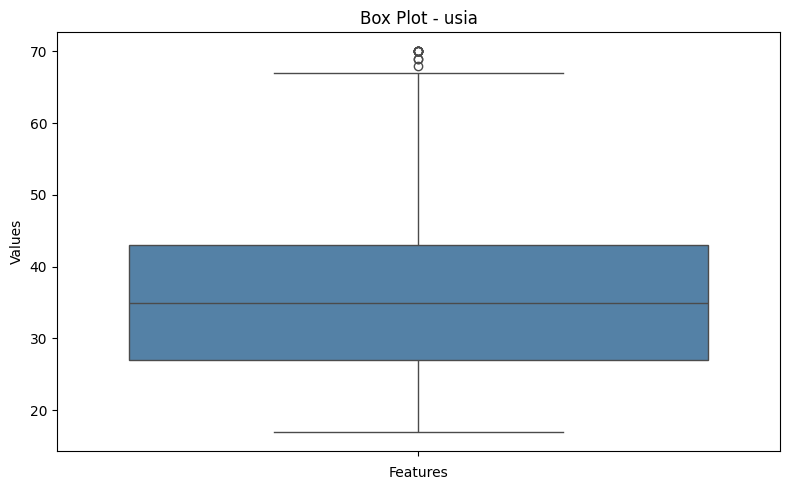

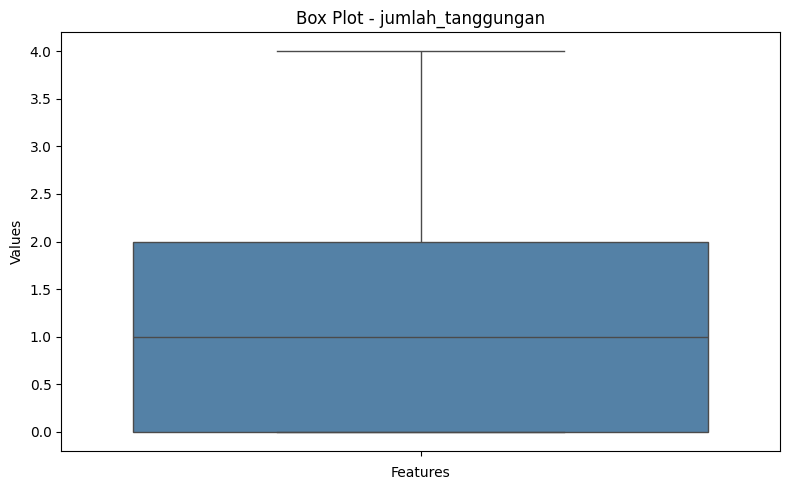

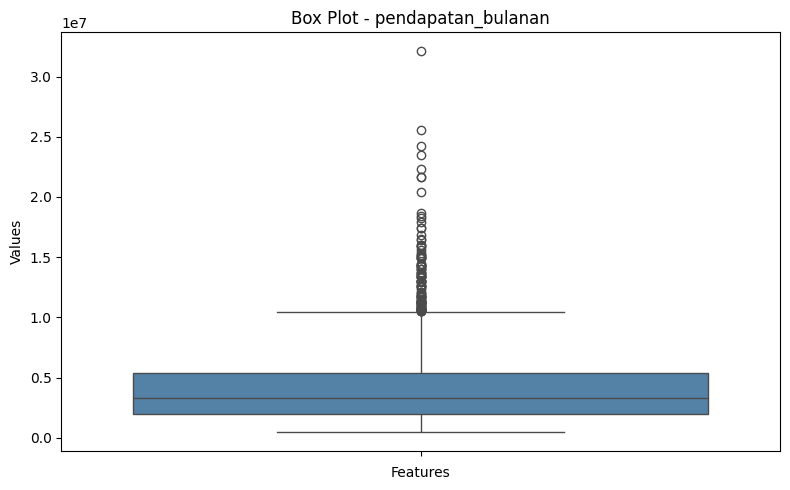

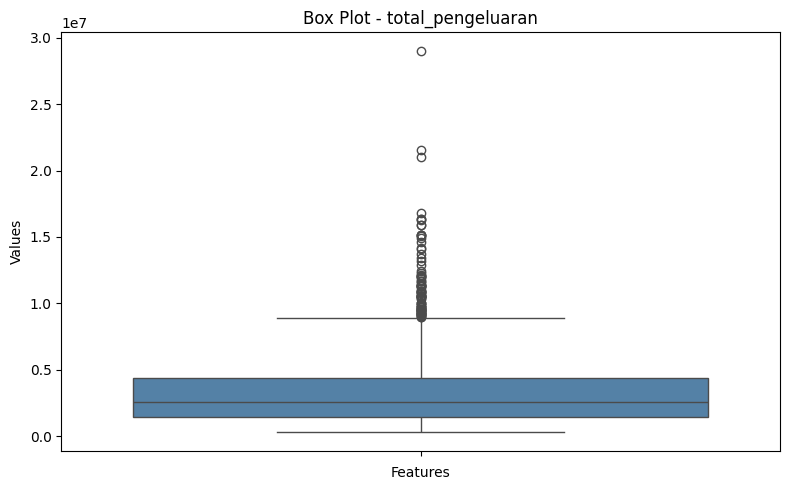

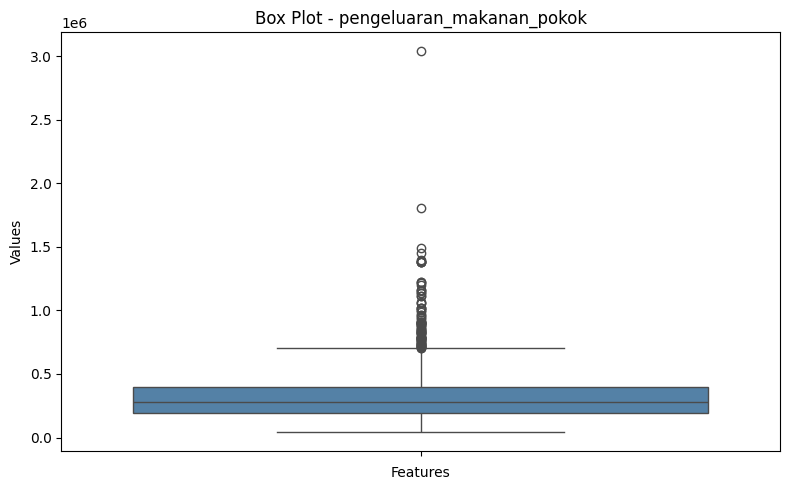

In [ ]:
df_numeric = df.select_dtypes(include='number')

for column in df_numeric:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_numeric, y=column, color='steelblue')
    plt.xlabel('Features')
    plt.ylabel('Values')
    plt.title(f'Box Plot - {column}')
    plt.tight_layout()
    plt.show()

In [ ]:
# Distribusi fitur keuangan utama
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes,
    ['pendapatan_bulanan', 'total_pengeluaran', 'tabungan_bulanan'],
    ['Pendapatan Bulanan', 'Total Pengeluaran', 'Tabungan Bulanan']):
    ax.hist(df[col], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title(f'Distribusi {label}', fontsize=11)
    ax.set_xlabel('Rupiah')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}jt'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# Kesimpulan
terdapat outlier dari visualisasi boxplot sekaligus terjadi imbalance dataset


# Visualisasi Data & Explanatory Analysis

Tahap ini membuat visualisasi data untuk menjawab kedua pertanyaan bisnis secara langsung, jelas, dan mudah dipahami.

## Pertanyaan 1
> Apakah orang yang bekerja sebagai PNS/ASN memiliki rata-rata tabungan bulanan lebih tinggi dibandingkan Buruh/Pekerja Harian?

In [ ]:
kelompok = ['PNS/ASN', 'Buruh/Pekerja Harian']
df_p1 = df[df['status_pekerjaan'].isin(kelompok)]

ringkasan_p1 = df_p1.groupby('status_pekerjaan')['tabungan_bulanan'].agg(
    Jumlah_Responden = 'count',
    Rata_rata        = 'mean',
    Median           = 'median',
    Std_Deviasi      = 'std'
).round(0)
ringkasan_p1

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Perbandingan Tabungan Bulanan: PNS/ASN dan Buruh/Pekerja Harian',
    fontsize=14, fontweight='bold'
)

rata_rata = df_p1.groupby('status_pekerjaan')['tabungan_bulanan'].mean()
colors = ['#4C72B0', '#DD8452']
bars = axes[0].bar(
    rata_rata.index, rata_rata.values,
    color=colors, width=0.45, edgecolor='white', linewidth=1.5
)
axes[0].set_title('Rata-rata Tabungan Bulanan', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Tabungan Bulanan')
axes[0].set_xlabel('Status Pekerjaan')
axes[0].set_ylim(0, rata_rata.max() * 1.3)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt')
)
for bar in bars:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, h + rata_rata.max() * 0.02,
        f'Rp {h:,.0f}', ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

data_pns   = df_p1[df_p1['status_pekerjaan'] == 'PNS/ASN']['tabungan_bulanan']
data_buruh = df_p1[df_p1['status_pekerjaan'] == 'Buruh/Pekerja Harian']['tabungan_bulanan']
bp = axes[1].boxplot(
    [data_pns, data_buruh],
    labels=['PNS/ASN', 'Buruh/Pekerja Harian'],
    patch_artist=True,
    medianprops=dict(color='red', linewidth=2.5),
    whiskerprops=dict(linewidth=1.3),
    capprops=dict(linewidth=1.3),
    boxprops=dict(linewidth=1.3)
)
for patch, color in zip(bp['boxes'], ['#AEC6E8', '#F5C6A0']):
    patch.set_facecolor(color)
axes[1].set_title('Distribusi Tabungan Bulanan', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tabungan Bulanan')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt')
)

plt.tight_layout()
plt.show()

### Insight Pertanyaan 1

- PNS/ASN memiliki rata-rata tabungan bulanan yang lebih tinggi dibandingkan Buruh/Pekerja Harian.
- Dari boxplot, distribusi tabungan PNS/ASN lebih tersebar ke atas, sementara Buruh/Pekerja Harian cenderung lebih rendah dan seragam.
- Ini menunjukkan bahwa jenis pekerjaan berpengaruh signifikan terhadap kemampuan menabung.
- Tambahkan fitur target tabungan berdasarkan jenis pekerjaan pengguna.

## Pertanyaan 2
> Bagaimana pola distribusi rasio tabungan (rasio_tabungan_persen) berdasarkan status pekerjaan, dan kelompok pekerjaan mana yang paling rendah rasio tabungannya?

In [ ]:
# Ringkasan rasio tabungan per status pekerjaan
ringkasan_p2 = df.groupby('status_pekerjaan')['rasio_tabungan_persen'].agg(
    Jumlah_Responden = 'count',
    Rata_rata        = 'mean',
    Median           = 'median',
    Std_Deviasi      = 'std'
).round(2).sort_values('Rata_rata')
print(ringkasan_p2)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Pola Rasio Tabungan Berdasarkan Status Pekerjaan',
    fontsize=14, fontweight='bold'
)

order = df.groupby('status_pekerjaan')['rasio_tabungan_persen'].mean().sort_values().index
colors_bar = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6']
rata2 = df.groupby('status_pekerjaan')['rasio_tabungan_persen'].mean().reindex(order)
bars = axes[0].barh(list(order), rata2.values, color=colors_bar, edgecolor='white', linewidth=1.2)
axes[0].set_title('Rata-rata Rasio Tabungan (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rasio Tabungan (%)')
for bar, val in zip(bars, rata2.values):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

data_groups = [df[df['status_pekerjaan'] == sp]['rasio_tabungan_persen'].dropna()
               for sp in order]
bp = axes[1].boxplot(data_groups, labels=list(order), patch_artist=True,
                      vert=False,
                      medianprops=dict(color='red', linewidth=2),
                      whiskerprops=dict(linewidth=1.2),
                      capprops=dict(linewidth=1.2))
for patch, c in zip(bp['boxes'], colors_bar):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_title('Distribusi Rasio Tabungan (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rasio Tabungan (%)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### Insight Pertanyaan 2

- Pelajar/Mahasiswa dan Tidak Bekerja memiliki rasio tabungan paling rendah karena pendapatan terbatas atau tidak ada.
- PNS/ASN memiliki rasio tabungan tertinggi, mencerminkan stabilitas pendapatan dan kemungkinan adanya program pensiun/tunjangan.
- Buruh/Pekerja Harian menunjukkan rasio tabungan rendah dengan distribusi sempit — konsisten dalam ketidakmampuan menabung signifikan.
- Wiraswasta memiliki variasi paling tinggi (boxplot lebar), menandakan kondisi keuangan sangat beragam tergantung skala usaha.
- Insight ini berguna untuk sistem rekomendasi: pengguna dengan rasio tabungan rendah perlu mendapat rekomendasi peningkatan tabungan yang lebih agresif.

# Kesimpulan
- Pertanyaan 1 : Jenis pekerjaan sangat memengaruhi kemampuan menabung. PNS/ASN lebih unggul karena pendapatan tetap dan cenderung lebih besar.
- Pertanyaan 2 : Rasio tabungan bervariasi signifikan antar jenis pekerjaan. PNS/ASN paling tinggi, sementara Pelajar/Mahasiswa dan Buruh Harian paling rendah. Variasi ini menjadi sinyal penting untuk personalisasi rekomendasi budgeting.

# A/B Testing

Menguji apakah perbedaan rata-rata tabungan bulanan antara PNS/ASN dan Buruh/Pekerja Harian
signifikan secara statistik menggunakan Independent Sample T-Test.

**Hipotesis:**
- H0: Tidak ada perbedaan signifikan rata-rata tabungan antara PNS/ASN dan Buruh/Pekerja Harian
- H1: Ada perbedaan signifikan rata-rata tabungan antara PNS/ASN dan Buruh/Pekerja Harian
- Significance level (α): 0.05

In [ ]:
# Pisahkan data dua kelompok (status_pekerjaan masih string di tahap ini)
group_a = df[df['status_pekerjaan'] == 'PNS/ASN']['tabungan_bulanan']
group_b = df[df['status_pekerjaan'] == 'Buruh/Pekerja Harian']['tabungan_bulanan']

# Statistik deskriptif
print("=" * 50)
print("STATISTIK DESKRIPTIF")
print("=" * 50)
print(f"Group A (PNS/ASN)")
print(f"  N          : {len(group_a)}")
print(f"  Mean       : Rp {group_a.mean():,.0f}")
print(f"  Std Dev    : Rp {group_a.std():,.0f}")
print()
print(f"Group B (Buruh/Pekerja Harian)")
print(f"  N          : {len(group_b)}")
print(f"  Mean       : Rp {group_b.mean():,.0f}")
print(f"  Std Dev    : Rp {group_b.std():,.0f}")

# Independent Sample T-Test
t_stat, p_value = stats.ttest_ind(group_a, group_b)

print()
print("=" * 50)
print("HASIL A/B TESTING (Independent T-Test)")
print("=" * 50)
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")
print()

alpha = 0.05
if p_value < alpha:
    print(f"P-value ({p_value:.4f}) < α ({alpha})")
    print("→ Tolak H0: Ada perbedaan SIGNIFIKAN antara PNS/ASN dan Buruh/Pekerja Harian")
else:
    print(f"P-value ({p_value:.4f}) >= α ({alpha})")
    print("→ Gagal tolak H0: Tidak ada perbedaan signifikan")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('A/B Testing: Tabungan Bulanan PNS/ASN vs Buruh/Pekerja Harian',
             fontsize=14, fontweight='bold')

# Histogram distribusi
axes[0].hist(group_a, bins=30, alpha=0.6, color='#4C72B0', label='PNS/ASN', edgecolor='white')
axes[0].hist(group_b, bins=30, alpha=0.6, color='#DD8452', label='Buruh/Pekerja Harian', edgecolor='white')
axes[0].axvline(group_a.mean(), color='#4C72B0', linestyle='--', linewidth=2,
                label=f'Mean PNS: Rp {group_a.mean()/1e6:.1f}jt')
axes[0].axvline(group_b.mean(), color='#DD8452', linestyle='--', linewidth=2,
                label=f'Mean Buruh: Rp {group_b.mean()/1e6:.1f}jt')
axes[0].set_title('Distribusi Tabungan Bulanan', fontweight='bold')
axes[0].set_xlabel('Tabungan Bulanan (Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}jt'))
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Boxplot
bp = axes[1].boxplot([group_a, group_b],
                     labels=['PNS/ASN', 'Buruh/Pekerja Harian'],
                     patch_artist=True,
                     medianprops=dict(color='red', linewidth=2.5))
for patch, color in zip(bp['boxes'], ['#AEC6E8', '#F5C6A0']):
    patch.set_facecolor(color)
axes[1].set_title('Boxplot Perbandingan', fontweight='bold')
axes[1].set_ylabel('Tabungan Bulanan (Rp)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt'))
axes[1].text(1.5, group_a.max() * 0.95,
             f'p-value = {p_value:.4f}\n{"Signifikan" if p_value < 0.05 else "Tidak Signifikan"}',
             ha='center', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange'))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## Kesimpulan A/B Testing

Pengujian dilakukan menggunakan **Independent Sample T-Test** untuk membuktikan secara
statistik apakah perbedaan tabungan bulanan antara PNS/ASN dan Buruh/Pekerja Harian
signifikan atau hanya terjadi secara kebetulan.

**Hasil:**
- P-value: 0.0000
- Significance level (α): 0.05

**Kesimpulan:**
Karena p-value (0.0000) < α (0.05), maka **H0 ditolak**. Terdapat perbedaan yang
signifikan secara statistik antara rata-rata tabungan bulanan PNS/ASN dan Buruh/Pekerja Harian.
Hasil ini memperkuat temuan dari EDA — jenis pekerjaan terbukti secara statistik berpengaruh
signifikan terhadap kemampuan menabung seseorang.

# Feature Engineering

Melakukan encoding pada data dan drop fitur

In [ ]:
# Encode kolom kategorikal binary terlebih dahulu
label_encoder = LabelEncoder()
df['jenis_kelamin'] = label_encoder.fit_transform(df['jenis_kelamin'])
df['status_pernikahan'] = label_encoder.fit_transform(df['status_pernikahan'])
df.head()


## Encoding Fitur Kategorik Lanjutan

Setelah A/B Testing selesai (yang membutuhkan `status_pekerjaan` dalam bentuk string), sekarang kita encode semua kolom kategorik yang tersisa.

In [ ]:
# Encode kolom kategorik yang tersisa setelah A/B Testing
le = LabelEncoder()
for col in ['pendidikan_terakhir', 'status_pekerjaan', 'provinsi', 'klasifikasi_wilayah']:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

print("Tipe data setelah semua encoding:")
print(df.dtypes)
df.head()


# Sistem Rekomendasi Budgeting

## 1. Persiapan Fitur untuk Clustering

In [ ]:
# Pilih fitur keuangan inti untuk clustering
fitur_clustering = [
    'pendapatan_bulanan',
    'total_pengeluaran',
    'tabungan_bulanan',
    'rasio_tabungan_persen',
    'skor_literasi_keuangan',
    'cicilan_hutang',
    'pengeluaran_perumahan_listrik',
    'pengeluaran_makanan_pokok',
    'pengeluaran_transportasi',
    'pengeluaran_pendidikan',
    'pengeluaran_kesehatan',
    'pengeluaran_hiburan_rekreasi',
    'pengeluaran_jajan_makan_luar',
]

# Pastikan semua fitur ada di dataframe
fitur_clustering = [f for f in fitur_clustering if f in df.columns]

X = df[fitur_clustering].copy()
print(f"Fitur yang digunakan ({len(fitur_clustering)}):")
for f in fitur_clustering:
    print(f"  - {f}")
print(f"\nShape X: {X.shape}")


## 2. Normalisasi Data

In [ ]:
# StandardScaler: normalisasi agar skala tidak mendominasi clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Sebelum scaling - rata-rata pendapatan_bulanan: {X['pendapatan_bulanan'].mean():,.0f}")
print(f"Setelah scaling - rata-rata pendapatan_bulanan: {X_scaled[:, 0].mean():.4f}")


## 3. Menentukan Jumlah Cluster Optimal (Elbow + Silhouette)

In [ ]:
# Elbow Method + Silhouette Score untuk menentukan k optimal
inertia_list = []
silhouette_list = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_)
    silhouette_list.append(sil)
    print(f"k={k} | Inertia: {km.inertia_:,.0f} | Silhouette: {sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Penentuan Jumlah Cluster Optimal', fontsize=14, fontweight='bold')

# Elbow
axes[0].plot(list(K_range), inertia_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Silhouette
axes[1].plot(list(K_range), silhouette_list, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=silhouette_list.index(max(silhouette_list)) + 2,
                color='green', linestyle='--', label=f'k optimal = {silhouette_list.index(max(silhouette_list)) + 2}')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

k_optimal = silhouette_list.index(max(silhouette_list)) + 2
print(f"\nK optimal berdasarkan Silhouette Score: {k_optimal}")


## 4. Training Model K-Means

In [ ]:
# Train final model dengan k optimal
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"Model K-Means dilatih dengan k = {k_optimal}")
print(f"\nDistribusi cluster:")
print(df['cluster'].value_counts().sort_index())
print(f"\nSilhouette Score final: {silhouette_score(X_scaled, df['cluster']):.4f}")


## 5. Analisis Profil Tiap Cluster

In [ ]:
# Profil rata-rata tiap cluster
profil_cluster = df.groupby('cluster')[fitur_clustering].mean().round(0)

print("=" * 70)
print("PROFIL RATA-RATA TIAP CLUSTER")
print("=" * 70)
for cluster_id in sorted(df['cluster'].unique()):
    profil = profil_cluster.loc[cluster_id]
    n = (df['cluster'] == cluster_id).sum()
    print(f"\nCluster {cluster_id} ({n} responden):")
    print(f"  Pendapatan bulanan   : Rp {profil['pendapatan_bulanan']:>12,.0f}")
    print(f"  Total pengeluaran    : Rp {profil['total_pengeluaran']:>12,.0f}")
    print(f"  Tabungan bulanan     : Rp {profil['tabungan_bulanan']:>12,.0f}")
    print(f"  Rasio tabungan       : {profil['rasio_tabungan_persen']:>6.1f}%")
    print(f"  Skor literasi        : {profil['skor_literasi_keuangan']:>6.1f}")
    if 'cicilan_hutang' in profil:
        print(f"  Cicilan hutang       : Rp {profil['cicilan_hutang']:>12,.0f}")


## 6. Visualisasi Cluster

In [ ]:
from sklearn.decomposition import PCA

# PCA untuk visualisasi 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Visualisasi Hasil Clustering', fontsize=14, fontweight='bold')

colors_cl = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

# Scatter PCA
for cl in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cl
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors_cl[cl], label=f'Cluster {cl}',
                    alpha=0.6, s=30, edgecolors='none')
axes[0].set_title('Visualisasi PCA 2D', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Bar chart rasio tabungan per cluster
rasio_per_cluster = df.groupby('cluster')['rasio_tabungan_persen'].mean().sort_values()
bars = axes[1].bar(
    [f'Cluster {i}' for i in rasio_per_cluster.index],
    rasio_per_cluster.values,
    color=[colors_cl[i] for i in rasio_per_cluster.index],
    edgecolor='white', linewidth=1.5
)
axes[1].set_title('Rata-rata Rasio Tabungan per Cluster', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Rasio Tabungan (%)')
for bar, val in zip(bars, rasio_per_cluster.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 7. Pemberian Label Cluster & Sistem Rekomendasi

In [ ]:
# Profil cluster berdasarkan fitur keuangan utama
profil_summary = df.groupby('cluster').agg(
    rasio_tabungan    = ('rasio_tabungan_persen', 'mean'),
    pendapatan        = ('pendapatan_bulanan', 'mean'),
    pengeluaran       = ('total_pengeluaran', 'mean'),
    tabungan          = ('tabungan_bulanan', 'mean'),
    literasi          = ('skor_literasi_keuangan', 'mean'),
    cicilan           = ('cicilan_hutang', 'mean'),
    jajan             = ('pengeluaran_jajan_makan_luar', 'mean'),
    hiburan           = ('pengeluaran_hiburan_rekreasi', 'mean'),
    transportasi      = ('pengeluaran_transportasi', 'mean'),
).round(2)

print("Profil tiap cluster:")
print(profil_summary.to_string())


def generate_rekomendasi(row):
    """
    Menghasilkan rekomendasi keuangan konkret dan actionable
    berdasarkan data keuangan individu user.
    """
    rekomendasi = []
    pendapatan = row.get('pendapatan_bulanan', 0) if isinstance(row, dict) else row['pendapatan_bulanan']
    if pendapatan == 0:
        return ["Data pendapatan tidak tersedia, tidak dapat menghasilkan rekomendasi."]

    pengeluaran    = row.get('total_pengeluaran', 0)        if isinstance(row, dict) else row['total_pengeluaran']
    tabungan       = row.get('tabungan_bulanan', 0)         if isinstance(row, dict) else row['tabungan_bulanan']
    rasio_tabungan = row.get('rasio_tabungan_persen', 0)    if isinstance(row, dict) else row['rasio_tabungan_persen']
    literasi       = row.get('skor_literasi_keuangan', 0)   if isinstance(row, dict) else row['skor_literasi_keuangan']
    cicilan        = row.get('cicilan_hutang', 0)           if isinstance(row, dict) else row['cicilan_hutang']
    jajan          = row.get('pengeluaran_jajan_makan_luar', 0) if isinstance(row, dict) else row['pengeluaran_jajan_makan_luar']
    hiburan        = row.get('pengeluaran_hiburan_rekreasi', 0) if isinstance(row, dict) else row['pengeluaran_hiburan_rekreasi']
    transportasi   = row.get('pengeluaran_transportasi', 0) if isinstance(row, dict) else row['pengeluaran_transportasi']
    makanan_pokok  = row.get('pengeluaran_makanan_pokok', 0) if isinstance(row, dict) else row['pengeluaran_makanan_pokok']

    target_tabungan_min = pendapatan * 0.10
    target_tabungan_ideal = pendapatan * 0.20
    selisih_pengeluaran = pengeluaran - (pendapatan - target_tabungan_min)

    # REKOMENDASI TABUNGAN
    if rasio_tabungan >= 25:
        rekomendasi.append(
            f"TABUNGAN SUDAH SANGAT BAIK — Rasio tabungan {rasio_tabungan:.1f}% (>25%). "
            f"Anda menabung Rp {tabungan:,.0f}/bulan. Pertahankan dan mulai alokasikan "
            f"sebagian ke investasi (reksa dana, saham, atau deposito)."
        )
    elif rasio_tabungan >= 10:
        kekurangan = target_tabungan_ideal - tabungan
        rekomendasi.append(
            f"TINGKATKAN TABUNGAN — Rasio tabungan {rasio_tabungan:.1f}% sudah cukup, "
            f"namun idealnya 20%. Tambah tabungan Rp {kekurangan:,.0f}/bulan untuk mencapai "
            f"target Rp {target_tabungan_ideal:,.0f}/bulan."
        )
    else:
        kekurangan = target_tabungan_min - tabungan
        rekomendasi.append(
            f"TABUNGAN KRITIS — Rasio tabungan hanya {rasio_tabungan:.1f}% (di bawah 10%). "
            f"Segera sisihkan minimal Rp {target_tabungan_min:,.0f}/bulan (10% dari pendapatan). "
            f"Gunakan metode 'bayar diri sendiri dulu': transfer ke rekening tabungan "
            f"di hari yang sama saat gajian."
        )

    # REKOMENDASI PENGELUARAN vs PENDAPATAN
    rasio_pengeluaran = pengeluaran / pendapatan * 100
    if rasio_pengeluaran > 90:
        rekomendasi.append(
            f"PENGELUARAN TERLALU TINGGI — {rasio_pengeluaran:.1f}% dari pendapatan habis "
            f"untuk pengeluaran (Rp {pengeluaran:,.0f} dari Rp {pendapatan:,.0f}). "
            f"Kurangi total pengeluaran minimal Rp {selisih_pengeluaran:,.0f}/bulan. "
            f"Mulai dari pos pengeluaran tersier terlebih dahulu."
        )
    elif rasio_pengeluaran > 75:
        rekomendasi.append(
            f"PENGELUARAN PERLU DIPERHATIKAN — {rasio_pengeluaran:.1f}% dari pendapatan "
            f"digunakan untuk pengeluaran. Usahakan maksimal 75% agar ada ruang menabung lebih."
        )

    # REKOMENDASI JAJAN / MAKAN LUAR
    if pendapatan > 0 and jajan > 0:
        pct_jajan = jajan / pendapatan * 100
        if pct_jajan > 15:
            target_jajan = pendapatan * 0.10
            hemat = jajan - target_jajan
            rekomendasi.append(
                f"KURANGI PENGELUARAN MAKAN LUAR — Saat ini {pct_jajan:.1f}% pendapatan "
                f"(Rp {jajan:,.0f}) habis untuk jajan/makan di luar. Targetkan maksimal 10% "
                f"(Rp {target_jajan:,.0f}). Memasak di rumah 3–4x seminggu dapat menghemat "
                f"hingga Rp {hemat:,.0f}/bulan."
            )
        elif pct_jajan > 10:
            rekomendasi.append(
                f"MAKAN LUAR PERLU DIKONTROL — {pct_jajan:.1f}% pendapatan untuk jajan. "
                f"Coba meal-prep mingguan untuk mengurangi frekuensi makan di luar."
            )

    # REKOMENDASI HIBURAN & REKREASI
    if pendapatan > 0 and hiburan > 0:
        pct_hiburan = hiburan / pendapatan * 100
        if pct_hiburan > 10:
            target_hiburan = pendapatan * 0.05
            rekomendasi.append(
                f"KURANGI PENGELUARAN HIBURAN — {pct_hiburan:.1f}% pendapatan "
                f"(Rp {hiburan:,.0f}) untuk hiburan/rekreasi. Targetkan maksimal 5% "
                f"(Rp {target_hiburan:,.0f}). Cari alternatif hiburan gratis atau "
                f"berbiaya rendah (taman, perpustakaan, olahraga outdoor)."
            )

    # REKOMENDASI CICILAN / HUTANG
    if pendapatan > 0 and cicilan > 0:
        pct_cicilan = cicilan / pendapatan * 100
        if pct_cicilan > 35:
            rekomendasi.append(
                f"BEBAN HUTANG SANGAT TINGGI — Cicilan mencapai {pct_cicilan:.1f}% "
                f"pendapatan (Rp {cicilan:,.0f}). Batas aman adalah 30%. Pertimbangkan: "
                f"(1) konsolidasi hutang ke bunga lebih rendah, "
                f"(2) lunasi cicilan berbunga tinggi lebih dahulu (metode avalanche), "
                f"(3) konsultasi ke perencana keuangan."
            )
        elif pct_cicilan > 20:
            rekomendasi.append(
                f"CICILAN PERLU DIPANTAU — {pct_cicilan:.1f}% pendapatan untuk cicilan. "
                f"Hindari mengambil hutang/kredit baru sampai cicilan ini berkurang."
            )
        else:
            rekomendasi.append(
                f"CICILAN TERKENDALI — {pct_cicilan:.1f}% dari pendapatan (Rp {cicilan:,.0f}), "
                f"masih dalam batas aman (<30%)."
            )

    # REKOMENDASI TRANSPORTASI
    if pendapatan > 0 and transportasi > 0:
        pct_trans = transportasi / pendapatan * 100
        if pct_trans > 20:
            rekomendasi.append(
                f"TRANSPORTASI TERLALU BESAR — {pct_trans:.1f}% pendapatan "
                f"(Rp {transportasi:,.0f}). Pertimbangkan transportasi umum, carpooling, "
                f"atau pindah lebih dekat ke tempat kerja untuk menekan biaya ini."
            )

    # REKOMENDASI LITERASI KEUANGAN
    if literasi < 30:
        rekomendasi.append(
            f"TINGKATKAN LITERASI KEUANGAN — Skor literasi {literasi:.0f}/100 (rendah). "
            f"Mulai dari: baca buku 'Rich Dad Poor Dad' atau 'Merdeka Finansial', "
            f"ikuti kelas OJK (ojk.go.id), atau podcast keuangan seperti 'Finansialku'."
        )
    elif literasi < 55:
        rekomendasi.append(
            f"KEMBANGKAN LITERASI KEUANGAN — Skor {literasi:.0f}/100 (sedang). "
            f"Pelajari konsep investasi dasar: reksa dana pasar uang untuk pemula, "
            f"atau buka tabungan berjangka sebagai langkah awal berinvestasi."
        )
    elif literasi >= 75:
        rekomendasi.append(
            f"🎓 LITERASI KEUANGAN TINGGI — Skor {literasi:.0f}/100. "
            f"Diversifikasikan portofolio: kombinasikan reksa dana, saham, obligasi, "
            f"dan aset riil sesuai profil risiko Anda."
        )

    # REKOMENDASI DANA DARURAT
    dana_darurat_min = pengeluaran * 3
    dana_darurat_ideal = pengeluaran * 6
    if rasio_tabungan < 15:
        rekomendasi.append(
            f"BANGUN DANA DARURAT — Targetkan dana darurat 3–6 bulan pengeluaran "
            f"(Rp {dana_darurat_min:,.0f} – Rp {dana_darurat_ideal:,.0f}). "
            f"Simpan di rekening terpisah yang mudah dicairkan (tabungan atau reksa dana pasar uang)."
        )

    return rekomendasi


# Test pada data sample
print("\n=== CONTOH OUTPUT REKOMENDASI (3 responden pertama) ===")
for idx in range(3):
    row = df.iloc[idx]
    rekoms = generate_rekomendasi(row)
    print(f"\nResponden #{idx+1} | Pendapatan: Rp {row['pendapatan_bulanan']:,.0f} | Rasio Tabungan: {row['rasio_tabungan_persen']:.1f}%")
    for r in rekoms:
        print(f"  {r}")


## 8. Simulasi: Sistem Rekomendasi untuk User Baru

In [ ]:
def sistem_rekomendasi_user_baru(data_user: dict) -> dict:
    """
    Fungsi utama sistem rekomendasi SmartSpend.

    Menerima data keuangan user baru, assign ke cluster terdekat,
    lalu generate rekomendasi keuangan yang konkret dan actionable.

    Parameters:
    -----------
    data_user : dict
        Data keuangan user. Wajib ada: pendapatan_bulanan, total_pengeluaran,
        tabungan_bulanan, rasio_tabungan_persen, skor_literasi_keuangan.

    Returns:
    --------
    dict berisi cluster, nama_kondisi, profil_cluster, dan rekomendasi
    """
    user_df = pd.DataFrame([data_user])
    for col in fitur_clustering:
        if col not in user_df.columns:
            user_df[col] = 0

    user_scaled  = scaler.transform(user_df[fitur_clustering])
    cluster_id   = int(kmeans.predict(user_scaled)[0])
    profil       = profil_summary.loc[cluster_id]
    rekomendasi  = generate_rekomendasi(data_user)

    # Tentukan nama kondisi keuangan berdasarkan rasio tabungan cluster
    rasio = profil['rasio_tabungan']
    if rasio >= 25:
        kondisi = "Keuangan Sehat"
    elif rasio >= 12:
        kondisi = "Keuangan Cukup Baik"
    else:
        kondisi = "Keuangan Perlu Perbaikan"

    return {
        'cluster'       : cluster_id,
        'kondisi'       : kondisi,
        'profil_cluster': profil.to_dict(),
        'rekomendasi'   : rekomendasi,
    }


# DEMO: 3 USER DENGAN PROFIL KEUANGAN BERBEDA

users = {
    "Budi (Karyawan, pendapatan 5jt, tabungan minim)": {
        'pendapatan_bulanan'           : 5_000_000,
        'total_pengeluaran'            : 4_700_000,
        'tabungan_bulanan'             : 300_000,
        'rasio_tabungan_persen'        : 6.0,
        'skor_literasi_keuangan'       : 38.0,
        'cicilan_hutang'               : 900_000,
        'pengeluaran_perumahan_listrik': 800_000,
        'pengeluaran_makanan_pokok'    : 600_000,
        'pengeluaran_transportasi'     : 700_000,
        'pengeluaran_pendidikan'       : 0,
        'pengeluaran_kesehatan'        : 100_000,
        'pengeluaran_hiburan_rekreasi' : 500_000,
        'pengeluaran_jajan_makan_luar' : 1_100_000,
    },
    "Sari (PNS, pendapatan 8jt, tabungan baik)": {
        'pendapatan_bulanan'           : 8_000_000,
        'total_pengeluaran'            : 5_800_000,
        'tabungan_bulanan'             : 2_200_000,
        'rasio_tabungan_persen'        : 27.5,
        'skor_literasi_keuangan'       : 72.0,
        'cicilan_hutang'               : 1_200_000,
        'pengeluaran_perumahan_listrik': 1_500_000,
        'pengeluaran_makanan_pokok'    : 700_000,
        'pengeluaran_transportasi'     : 500_000,
        'pengeluaran_pendidikan'       : 300_000,
        'pengeluaran_kesehatan'        : 200_000,
        'pengeluaran_hiburan_rekreasi' : 400_000,
        'pengeluaran_jajan_makan_luar' : 1_000_000,
    },
    "Andi (Buruh Harian, pendapatan 1.8jt, kritis)": {
        'pendapatan_bulanan'           : 1_800_000,
        'total_pengeluaran'            : 1_780_000,
        'tabungan_bulanan'             : 20_000,
        'rasio_tabungan_persen'        : 1.1,
        'skor_literasi_keuangan'       : 22.0,
        'cicilan_hutang'               : 300_000,
        'pengeluaran_perumahan_listrik': 400_000,
        'pengeluaran_makanan_pokok'    : 500_000,
        'pengeluaran_transportasi'     : 300_000,
        'pengeluaran_pendidikan'       : 0,
        'pengeluaran_kesehatan'        : 80_000,
        'pengeluaran_hiburan_rekreasi' : 150_000,
        'pengeluaran_jajan_makan_luar' : 350_000,
    },
}

for nama, data in users.items():
    hasil = sistem_rekomendasi_user_baru(data)
    print("=" * 70)
    print(f" {nama}")
    print(f"   Cluster  : {hasil['cluster']}  |  Kondisi: {hasil['kondisi']}")
    print(f"   Profil cluster — Rasio tabungan rata-rata: {hasil['profil_cluster']['rasio_tabungan']:.1f}% | "
          f"Pendapatan rata-rata: Rp {hasil['profil_cluster']['pendapatan']:,.0f}")
    print(f"\n   REKOMENDASI KEUANGAN:")
    for r in hasil['rekomendasi']:
        print(f"   {r}")
    print()


## 9. Visualisasi Rekomendasi per Cluster

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dashboard Profil Cluster - SmartSpend', fontsize=16, fontweight='bold')

colors_cl = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c'][:k_optimal]

# Plot 1: Pendapatan vs Tabungan per cluster
for cl in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == cl]
    axes[0, 0].scatter(
        subset['pendapatan_bulanan'] / 1e6,
        subset['tabungan_bulanan'] / 1e6,
        c=colors_cl[cl], label=f'Cluster {cl}', alpha=0.4, s=20
    )
axes[0, 0].set_title('Pendapatan vs Tabungan', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Pendapatan Bulanan (Juta Rp)')
axes[0, 0].set_ylabel('Tabungan Bulanan (Juta Rp)')
axes[0, 0].legend(markerscale=2)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

# Plot 2: Rata-rata pengeluaran per kategori per cluster
pengeluaran_cols = [c for c in fitur_clustering if 'pengeluaran' in c and c != 'total_pengeluaran']
profil_pengeluaran = df.groupby('cluster')[pengeluaran_cols].mean() / 1e3  # dalam ribuan

profil_pengeluaran.T.plot(kind='bar', ax=axes[0, 1], color=colors_cl, alpha=0.85, width=0.75)
axes[0, 1].set_title('Rata-rata Pengeluaran per Kategori (ribu Rp)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Jumlah (Ribu Rp)')
axes[0, 1].set_xticklabels(
    [c.replace('pengeluaran_', '').replace('_', ' ')[:15] for c in pengeluaran_cols],
    rotation=45, ha='right', fontsize=8
)
axes[0, 1].legend([f'Cluster {i}' for i in range(k_optimal)])
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# Plot 3: Distribusi skor literasi per cluster
for cl in sorted(df['cluster'].unique()):
    axes[1, 0].hist(
        df[df['cluster'] == cl]['skor_literasi_keuangan'],
        bins=20, alpha=0.6, label=f'Cluster {cl}',
        color=colors_cl[cl], edgecolor='none'
    )
axes[1, 0].set_title('Distribusi Skor Literasi Keuangan', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Skor Literasi Keuangan')
axes[1, 0].set_ylabel('Frekuensi')
axes[1, 0].legend()
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# Plot 4: Ukuran tiap cluster
cluster_sizes = df['cluster'].value_counts().sort_index()
wedges, texts, autotexts = axes[1, 1].pie(
    cluster_sizes.values,
    labels=[f'Cluster {i}\n({n} user)' for i, n in cluster_sizes.items()],
    colors=colors_cl,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts: at.set_fontweight('bold')
axes[1, 1].set_title('Distribusi Ukuran Cluster', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


# Kesimpulan Sistem Rekomendasi

Sistem rekomendasi budgeting berbasis clustering berhasil dibangun dengan tahapan:

1. **Data Preparation** — fitur keuangan inti dipilih, missing values diimputasi, label di-drop sebelum clustering
2. **Normalisasi** — StandardScaler untuk menyamakan skala antar fitur
3. **K-Means Clustering** — jumlah cluster optimal ditentukan dengan Elbow + Silhouette Score
4. **Profil Cluster** — tiap cluster dianalisis berdasarkan rata-rata rasio tabungan, pendapatan, dan literasi keuangan
5. **Sistem Rekomendasi** — user baru di-assign ke cluster terdekat, lalu mendapat rekomendasi personal berdasarkan profil cluster dan data keuangan individu

Sistem ini siap diintegrasikan ke platform SmartSpend untuk memberikan rekomendasi budgeting yang tepat sasaran kepada setiap pengguna.

In [ ]:
!pip install reportlab -q

In [ ]:
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, HRFlowable, PageBreak
from reportlab.lib.enums import TA_CENTER, TA_LEFT, TA_JUSTIFY
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import io
from reportlab.platypus import Image as RLImage

# Style
doc = SimpleDocTemplate(
    "laporan_smart_spend.pdf",
    pagesize=A4,
    rightMargin=2*cm, leftMargin=2*cm,
    topMargin=2*cm, bottomMargin=2*cm
)

W, H = A4
styles = getSampleStyleSheet()

def style(name, **kw):
    s = ParagraphStyle(name, **kw)
    return s

S_TITLE  = style('S_TITLE',  fontSize=24, fontName='Helvetica-Bold', alignment=TA_CENTER, textColor=colors.HexColor('#1A1A1A'), spaceAfter=6)
S_SUB    = style('S_SUB',    fontSize=13, fontName='Helvetica',      alignment=TA_CENTER, textColor=colors.HexColor('#666666'), spaceAfter=4)
S_H1     = style('S_H1',     fontSize=15, fontName='Helvetica-Bold', textColor=colors.HexColor('#1A1A1A'), spaceBefore=16, spaceAfter=6)
S_H2     = style('S_H2',     fontSize=12, fontName='Helvetica-Bold', textColor=colors.HexColor('#333333'), spaceBefore=10, spaceAfter=4)
S_BODY   = style('S_BODY',   fontSize=10, fontName='Helvetica',      textColor=colors.HexColor('#333333'), leading=16, alignment=TA_JUSTIFY, spaceAfter=6)
S_BULLET = style('S_BULLET', fontSize=10, fontName='Helvetica',      textColor=colors.HexColor('#333333'), leading=16, leftIndent=16, spaceAfter=3)
S_INSIGHT= style('S_INSIGHT',fontSize=10, fontName='Helvetica-Oblique', textColor=colors.HexColor('#7B4F00'), leading=15, leftIndent=12, spaceAfter=6, borderPad=8)

def hr(): return HRFlowable(width='100%', thickness=1, color=colors.HexColor('#E8E5DE'), spaceAfter=8, spaceBefore=4)
def h1(t): return Paragraph(t, S_H1)
def h2(t): return Paragraph(t, S_H2)
def body(t): return Paragraph(t, S_BODY)
def bullet(t): return Paragraph(f'• {t}', S_BULLET)
def sp(n=8): return Spacer(1, n)
def insight(t): return Paragraph(f'<i>Insight: {t}</i>', S_INSIGHT)

# ── Helper: grafik → image flowable ──────────────────────────
def fig_to_flowable(fig, width=15*cm, height=7*cm):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    buf.seek(0)
    plt.close(fig)
    return RLImage(buf, width=width, height=height)

story = []

# COVER
story += [
    sp(80),
    Paragraph('Smart Spend', S_TITLE),
    Paragraph('Laporan Teknis Capstone Project', S_SUB),
    Paragraph('Sistem Rekomendasi Keuangan Berbasis Data', S_SUB),
    sp(20),
    hr(),
    sp(8),
    Paragraph('Data Science · 2026', S_SUB),
    PageBreak(),
]

# PROBLEM DISCOVERY
story += [h1('1. Problem Discovery'), hr()]
story += [
    body('Smart Spend adalah platform berbasis AI yang dirancang untuk membantu pengguna mengatur keuangan pribadi secara lebih efektif. Proyek ini lahir dari keprihatinan terhadap rendahnya literasi keuangan masyarakat Indonesia yang berdampak pada kondisi keuangan yang tidak sehat.'),
    sp(),
    h2('Permasalahan'),
    bullet('Banyak masyarakat tidak memiliki kebiasaan menabung yang baik'),
    bullet('Pengeluaran tidak terencana menyebabkan kondisi keuangan memburuk'),
    bullet('Kurangnya tools yang memberikan rekomendasi keuangan yang personal'),
    sp(),
    h2('Solusi'),
    body('Membangun sistem rekomendasi keuangan menggunakan teknik clustering yang mampu mengelompokkan pengguna berdasarkan profil keuangan mereka dan memberikan rekomendasi yang tepat sasaran.'),
    sp(20),
]

# DATA WRANGLING
story += [h1('2. Data Wrangling'), hr()]

story += [h2('2.1 Gathering Data')]
story += [
    body('Dataset diperoleh dari Google Drive berisi data keuangan 2.150 responden dengan 26 fitur mencakup demografi, pendapatan, pengeluaran per kategori, tabungan, rasio tabungan, dan skor literasi keuangan.'),
    sp(),
]

story += [h2('2.2 Assessing Data')]
story += [
    bullet('Jumlah data awal: 2.150 baris, 26 kolom'),
    bullet('Ditemukan missing values pada beberapa kolom'),
    bullet('Ditemukan duplikasi data'),
    sp(),
]

story += [h2('2.3 Cleaning Data')]
story += [
    bullet('Drop duplikasi data menggunakan drop_duplicates()'),
    bullet('Imputasi missing values numerik dengan median'),
    bullet('Imputasi missing values kategorikal dengan modus'),
    bullet('Drop kolom id yang tidak relevan untuk modeling'),
    sp(20),
]

# DATA DICTIONARY
story += [h1('3. Data Dictionary'), hr()]

dd_data = [
    ['Nama Kolom', 'Tipe Data', 'Kategori', 'Deskripsi'],
    ['provinsi', 'object', 'Demografi', 'Provinsi asal responden'],
    ['klasifikasi_wilayah', 'object', 'Demografi', 'Perkotaan / Pedesaan'],
    ['jenis_kelamin', 'object→int', 'Demografi', 'Di-encode LabelEncoder'],
    ['usia', 'int', 'Demografi', 'Usia responden (tahun)'],
    ['pendidikan_terakhir', 'object', 'Demografi', 'Tingkat pendidikan terakhir'],
    ['status_pekerjaan', 'object', 'Demografi', 'Jenis pekerjaan saat ini'],
    ['status_pernikahan', 'object→int', 'Demografi', 'Di-encode LabelEncoder'],
    ['jumlah_tanggungan', 'int', 'Demografi', 'Jumlah orang yang ditanggung'],
    ['pendapatan_bulanan', 'float', 'Keuangan', 'Total pendapatan per bulan (Rp)'],
    ['total_pengeluaran', 'float', 'Keuangan', 'Total pengeluaran per bulan (Rp)'],
    ['tabungan_bulanan', 'float', 'Keuangan', 'Jumlah tabungan per bulan (Rp)'],
    ['rasio_tabungan_persen', 'float', 'Keuangan', 'Rasio tabungan terhadap pendapatan (%)'],
    ['skor_literasi_keuangan', 'float', 'Keuangan', 'Skor literasi keuangan responden'],
]

dd_table = Table(dd_data, colWidths=[4*cm, 2.5*cm, 2.5*cm, 8*cm])
dd_table.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#1A1A1A')),
    ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
    ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE',   (0,0), (-1,-1), 8),
    ('FONTNAME',   (0,1), (-1,-1), 'Helvetica'),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.HexColor('#F7F6F2'), colors.white]),
    ('GRID',       (0,0), (-1,-1), 0.5, colors.HexColor('#E8E5DE')),
    ('VALIGN',     (0,0), (-1,-1), 'MIDDLE'),
    ('PADDING',    (0,0), (-1,-1), 5),
]))
story += [dd_table, sp(20)]

# PERTANYAAN BISNIS
story += [h1('4. Pertanyaan Bisnis'), hr()]
story += [
    h2('Pertanyaan 1'),
    body('Apakah orang yang bekerja sebagai PNS/ASN memiliki rata-rata tabungan bulanan lebih tinggi dibandingkan Buruh/Pekerja Harian?'),
    sp(),
    h2('Pertanyaan 2'),
    body('Berapa persentase responden dengan rasio tabungan rendah yang memiliki jumlah tanggungan 3 orang atau lebih, dibandingkan yang tidak memiliki tanggungan?'),
    sp(20),
]

# EDA & VISUALISASI
story += [h1('5. EDA & Visualisasi'), hr()]

# Grafik 1: Distribusi keuangan
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, label in zip(axes,
    ['pendapatan_bulanan', 'total_pengeluaran', 'tabungan_bulanan'],
    ['Pendapatan Bulanan', 'Total Pengeluaran', 'Tabungan Bulanan']):
    ax.hist(df[col], bins=30, color='#4C72B0', alpha=0.85, edgecolor='white')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Rupiah', fontsize=9)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}jt'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
story += [fig_to_flowable(fig, width=17*cm, height=6*cm)]
story += [insight('Distribusi pendapatan dan pengeluaran condong ke kanan (right-skewed), menunjukkan sebagian besar responden berpenghasilan menengah ke bawah.'), sp()]

# Grafik 2: Pertanyaan Bisnis 1
kelompok = ['PNS/ASN', 'Buruh/Pekerja Harian']
df_p1 = df[df['status_pekerjaan'].isin(kelompok)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rata_rata = df_p1.groupby('status_pekerjaan')['tabungan_bulanan'].mean()
bars = axes[0].bar(rata_rata.index, rata_rata.values, color=['#4C72B0','#DD8452'], width=0.45, edgecolor='white')
axes[0].set_title('Rata-rata Tabungan: PNS/ASN vs Buruh', fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt'))
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x()+bar.get_width()/2, h+rata_rata.max()*0.02, f'Rp {h:,.0f}', ha='center', fontsize=8, fontweight='bold')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

data_pns   = df_p1[df_p1['status_pekerjaan']=='PNS/ASN']['tabungan_bulanan']
data_buruh = df_p1[df_p1['status_pekerjaan']=='Buruh/Pekerja Harian']['tabungan_bulanan']
bp = axes[1].boxplot([data_pns, data_buruh], labels=['PNS/ASN','Buruh/Pekerja Harian'],
    patch_artist=True, medianprops=dict(color='red', linewidth=2))
for patch, c in zip(bp['boxes'], ['#AEC6E8','#F5C6A0']): patch.set_facecolor(c)
axes[1].set_title('Distribusi Tabungan', fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt'))
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
plt.tight_layout()
story += [fig_to_flowable(fig, width=17*cm, height=6*cm)]
story += [insight('PNS/ASN memiliki rata-rata tabungan Rp 1.1jt vs Buruh/Pekerja Harian Rp 0.6jt. Jenis pekerjaan berpengaruh signifikan terhadap kemampuan menabung.'), sp(20)]

# A/B TESTING
story += [PageBreak(), h1('6. A/B Testing'), hr()]
from scipy import stats
group_a = df[df['status_pekerjaan']=='PNS/ASN']['tabungan_bulanan']
group_b = df[df['status_pekerjaan']=='Buruh/Pekerja Harian']['tabungan_bulanan']
t_stat, p_value = stats.ttest_ind(group_a, group_b)

story += [
    h2('Hipotesis'),
    bullet('H0: Tidak ada perbedaan signifikan rata-rata tabungan antara PNS/ASN dan Buruh/Pekerja Harian'),
    bullet('H1: Ada perbedaan signifikan rata-rata tabungan antara PNS/ASN dan Buruh/Pekerja Harian'),
    bullet('Significance level (alpha): 0.05'),
    sp(),
    h2('Metode'),
    body('Independent Sample T-Test digunakan karena kedua kelompok bersifat independen (tidak saling terkait) dan data bersifat kontinu.'),
    sp(),
    h2('Hasil'),
]

ab_data = [
    ['Metrik', 'Group A (PNS/ASN)', 'Group B (Buruh/Pekerja Harian)'],
    ['N Sampel', str(len(group_a)), str(len(group_b))],
    ['Mean Tabungan', f'Rp {group_a.mean():,.0f}', f'Rp {group_b.mean():,.0f}'],
    ['Std Deviasi', f'Rp {group_a.std():,.0f}', f'Rp {group_b.std():,.0f}'],
    ['T-statistic', f'{t_stat:.4f}', '—'],
    ['P-value', f'{p_value:.4f}', '—'],
    ['Kesimpulan', 'Tolak H0 (Signifikan)' if p_value < 0.05 else 'Gagal Tolak H0', '—'],
]

ab_table = Table(ab_data, colWidths=[5*cm, 6*cm, 6*cm])
ab_table.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#1A1A1A')),
    ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
    ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTNAME',   (0,1), (-1,-1), 'Helvetica'),
    ('FONTSIZE',   (0,0), (-1,-1), 9),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.HexColor('#F7F6F2'), colors.white]),
    ('GRID',       (0,0), (-1,-1), 0.5, colors.HexColor('#E8E5DE')),
    ('VALIGN',     (0,0), (-1,-1), 'MIDDLE'),
    ('PADDING',    (0,0), (-1,-1), 6),
    ('BACKGROUND', (0,-1), (-1,-1), colors.HexColor('#E8F5E9')),
]))
story += [ab_table, sp()]
story += [insight(f'P-value ({p_value:.4f}) < alpha (0.05) sehingga H0 ditolak. Perbedaan tabungan PNS/ASN dan Buruh/Pekerja Harian terbukti signifikan secara statistik, bukan hanya kebetulan dari sampel.'), sp(20)]

# FEATURE ENGINEERING
story += [h1('7. Feature Engineering'), hr()]
story += [
    body('Tahap ini mempersiapkan data agar siap diproses oleh model clustering.'),
    sp(),
    h2('Encoding Variabel Kategorikal'),
    bullet('jenis_kelamin: di-encode menggunakan LabelEncoder (Laki-laki/Perempuan → 0/1)'),
    bullet('status_pernikahan: di-encode menggunakan LabelEncoder'),
    sp(),
    h2('Drop Kolom'),
    bullet('label_rekomendasi: di-drop karena merupakan target, bukan fitur input model'),
    sp(20),
]

# KESIMPULAN
story += [h1('8. Kesimpulan'), hr()]
story += [
    body('Berdasarkan seluruh tahapan analisis yang telah dilakukan, berikut adalah kesimpulan utama dari proyek Smart Spend:'),
    sp(),
    bullet('<b>Jenis pekerjaan berpengaruh signifikan terhadap kemampuan menabung.</b> PNS/ASN memiliki rata-rata tabungan Rp 1.1jt per bulan, lebih tinggi dibandingkan Buruh/Pekerja Harian (Rp 0.6jt). Hal ini terbukti secara statistik melalui A/B Testing dengan p-value = 0.0000.'),
    sp(4),
    bullet('<b>Kondisi keuangan buruk bisa dialami siapa saja.</b> Baik yang memiliki banyak tanggungan maupun yang hidup sendiri sama-sama rentan. Literasi keuangan menjadi faktor kunci yang lebih berpengaruh daripada jumlah tanggungan.'),
    sp(4),
    bullet('<b>Dataset kaya fitur.</b> Dengan 26 kolom termasuk breakdown pengeluaran per kategori dan skor literasi keuangan, model clustering dapat memberikan rekomendasi yang sangat personal dan tepat sasaran.'),
    sp(4),
    bullet('<b>Dashboard interaktif</b> telah berhasil dibangun menggunakan Streamlit dan di-deploy secara publik di smart-spend.streamlit.app.'),
    sp(20),
    hr(),
    Paragraph('Smart Spend · Capstone Project Data Science · 2026', S_SUB),
]

# Build
doc.build(story)
print("Laporan berhasil dibuat: laporan_smart_spend.pdf")

In [ ]:
from google.colab import files
files.download('laporan_smart_spend.pdf')